# 03 — Port Weather: Ingest & Clean
**MSBA 305 | Maritime Shipping Intelligence Pipeline**

**Source:** OpenWeatherMap API (openweathermap.org)
**Output:** `data/clean/port_weather_clean.csv`

---
### Why weather data for a shipping pipeline?
Weather directly impacts shipping operations:
- High wind speed → port closures, delayed departures
- Low visibility → navigation restrictions
- Storm conditions → route diversions = longer transit times + higher fuel costs

This source gives us **real-time operational context** at the world's busiest ports.

---
### Data Source Appraisal (Section 4.1.1 of rubric)
| Dimension | Detail |
|-----------|--------|
| **Origin** | OpenWeatherMap — aggregates global weather stations + satellite |
| **Format** | JSON API response (nested) → normalized DataFrame |
| **Volume** | 100 ports × daily = ~36,500 rows/year |
| **Update frequency** | Real-time (current), historical via paid tier |
| **Quality issues** | Missing wind_gust field in calm weather, API rate limits |
| **Free tier** | 1,000 calls/day — sufficient for 100 ports (108 calls/day) |
| **Bias** | Point measurements — may not reflect full port area conditions |

## 0. Setup

In [9]:
import os, sys, json, time, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
from datetime import datetime
warnings.filterwarnings('ignore')

# ── Environment detection: works in Colab and local/GitHub clone ──────────
try:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE = '/content/drive/MyDrive/repo'
    print('Running in Google Colab')
except ImportError:
    BASE = os.path.abspath(os.path.join(os.getcwd(), '..'))
    print(f'Running locally — BASE: {BASE}')

CLEAN_DIR  = os.path.join(BASE, 'data', 'clean')
RAW_DIR    = os.path.join(BASE, 'data', 'raw')
CLEAN_PATH = os.path.join(CLEAN_DIR, 'port_weather_clean.csv')
RAW_PATH   = os.path.join(RAW_DIR,   'port_weather_raw.json')
os.makedirs(CLEAN_DIR, exist_ok=True)

# API key — paste here for Colab, or set WEATHER_API_KEY env var for local/CI
WEATHER_API_KEY = os.environ.get('WEATHER_API_KEY', 'YOUR_OPENWEATHER_KEY_HERE')

print('Setup complete')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/repo/notebooks
Setup complete


## 1. Define Top 20 Global Shipping Ports
Selected based on UNCTAD container throughput rankings.

In [10]:
TOP_PORTS = [
    {'name':'Shanghai',          'country':'CN', 'lat':31.2304,  'lon':121.4737, 'rank':1},
    {'name':'Singapore',         'country':'SG', 'lat': 1.2966,  'lon':103.8006, 'rank':2},
    {'name':'Ningbo-Zhoushan',   'country':'CN', 'lat':29.8683,  'lon':121.5440, 'rank':3},
    {'name':'Shenzhen',          'country':'CN', 'lat':22.5431,  'lon':114.0579, 'rank':4},
    {'name':'Guangzhou',         'country':'CN', 'lat':23.1291,  'lon':113.2644, 'rank':5},
    {'name':'Busan',             'country':'KR', 'lat':35.1796,  'lon':129.0756, 'rank':6},
    {'name':'Tianjin',           'country':'CN', 'lat':39.3434,  'lon':117.3616, 'rank':7},
    {'name':'Hong Kong',         'country':'HK', 'lat':22.3193,  'lon':114.1694, 'rank':8},
    {'name':'Rotterdam',         'country':'NL', 'lat':51.9225,  'lon':  4.4792, 'rank':9},
    {'name':'Dubai',             'country':'AE', 'lat':24.9965,  'lon': 55.0272, 'rank':10},
    {'name':'Port Klang',        'country':'MY', 'lat': 3.0000,  'lon':101.4000, 'rank':11},
    {'name':'Antwerp',           'country':'BE', 'lat':51.2194,  'lon':  4.4025, 'rank':12},
    {'name':'Xiamen',            'country':'CN', 'lat':24.4798,  'lon':118.0894, 'rank':13},
    {'name':'Los Angeles',       'country':'US', 'lat':33.7290,  'lon':-118.262, 'rank':14},
    {'name':'Hamburg',           'country':'DE', 'lat':53.5753,  'lon': 10.0153, 'rank':15},
    {'name':'Long Beach',        'country':'US', 'lat':33.7548,  'lon':-118.2164,'rank':16},
    {'name':'Tanjung Pelepas',   'country':'MY', 'lat': 1.3634,  'lon':103.5521, 'rank':17},
    {'name':'Kaohsiung',         'country':'TW', 'lat':22.6273,  'lon':120.3014, 'rank':18},
    {'name':'Dalian',            'country':'CN', 'lat':38.9140,  'lon':121.6147, 'rank':19},
    {'name':'New York',          'country':'US', 'lat':40.6943,  'lon': -74.1239,'rank':20},
    {'name':'Tanjung Priok',     'country':'ID', 'lat': -6.1000, 'lon':106.8800, 'rank':21},
    {'name':'Colombo',           'country':'LK', 'lat': 6.9271,  'lon': 79.8612, 'rank':22},
    {'name':'Valencia',          'country':'ES', 'lat':39.4561,  'lon': -0.3230, 'rank':23},
    {'name':'Laem Chabang',      'country':'TH', 'lat':13.0800,  'lon':100.8800, 'rank':24},
    {'name':'Algeciras',         'country':'ES', 'lat':36.1408,  'lon': -5.4531, 'rank':25},
    {'name':'Ho Chi Minh City',  'country':'VN', 'lat':10.7769,  'lon':106.7009, 'rank':26},
    {'name':'Bremen/Bremerhaven','country':'DE', 'lat':53.5396,  'lon':  8.5809, 'rank':27},
    {'name':'Jawaharlal Nehru',  'country':'IN', 'lat':18.9500,  'lon': 72.9500, 'rank':28},
    {'name':'Qingdao',           'country':'CN', 'lat':36.0671,  'lon':120.3826, 'rank':29},
    {'name':'Felixstowe',        'country':'GB', 'lat':51.9500,  'lon':  1.3500, 'rank':30},
    {'name':'Manila',            'country':'PH', 'lat':14.5764,  'lon':120.9653, 'rank':31},
    {'name':'Lianyungang',       'country':'CN', 'lat':34.7500,  'lon':119.4400, 'rank':32},
    {'name':'Tokyo',             'country':'JP', 'lat':35.6262,  'lon':139.7736, 'rank':33},
    {'name':'Yokohama',          'country':'JP', 'lat':35.4437,  'lon':139.6380, 'rank':34},
    {'name':'Osaka',             'country':'JP', 'lat':34.6540,  'lon':135.4300, 'rank':35},
    {'name':'Nagoya',            'country':'JP', 'lat':35.0500,  'lon':136.8833, 'rank':36},
    {'name':'Kobe',              'country':'JP', 'lat':34.6901,  'lon':135.1956, 'rank':37},
    {'name':'Suzhou',            'country':'CN', 'lat':31.3100,  'lon':120.6200, 'rank':38},
    {'name':'Wuhan',             'country':'CN', 'lat':30.5928,  'lon':114.3055, 'rank':39},
    {'name':'Jebel Ali',         'country':'AE', 'lat':24.9994,  'lon': 55.0540, 'rank':40},
    {'name':'Salalah',           'country':'OM', 'lat':16.9400,  'lon': 54.0000, 'rank':41},
    {'name':'Piraeus',           'country':'GR', 'lat':37.9417,  'lon': 23.6464, 'rank':42},
    {'name':'Genoa',             'country':'IT', 'lat':44.4056,  'lon':  8.9463, 'rank':43},
    {'name':'Barcelona',         'country':'ES', 'lat':41.3700,  'lon':  2.1600, 'rank':44},
    {'name':'Marseille',         'country':'FR', 'lat':43.2965,  'lon':  5.3698, 'rank':45},
    {'name':'Le Havre',          'country':'FR', 'lat':49.4938,  'lon':  0.1077, 'rank':46},
    {'name':'Gioia Tauro',       'country':'IT', 'lat':38.4300,  'lon': 15.8900, 'rank':47},
    {'name':'Ambarli',           'country':'TR', 'lat':40.9500,  'lon': 28.6900, 'rank':48},
    {'name':'Istanbul',          'country':'TR', 'lat':41.0082,  'lon': 28.9784, 'rank':49},
    {'name':'Mersin',            'country':'TR', 'lat':36.8000,  'lon': 34.6333, 'rank':50},
    {'name':'Haifa',             'country':'IL', 'lat':32.8191,  'lon': 34.9983, 'rank':51},
    {'name':'Alexandria',        'country':'EG', 'lat':31.2001,  'lon': 29.9187, 'rank':52},
    {'name':'Damietta',          'country':'EG', 'lat':31.4167,  'lon': 31.8167, 'rank':53},
    {'name':'Casablanca',        'country':'MA', 'lat':33.5731,  'lon': -7.5898, 'rank':54},
    {'name':'Mombasa',           'country':'KE', 'lat': -4.0500, 'lon': 39.6700, 'rank':55},
    {'name':'Durban',            'country':'ZA', 'lat':-29.8587, 'lon': 31.0218, 'rank':56},
    {'name':'Lagos',             'country':'NG', 'lat': 6.4500,  'lon':  3.4000, 'rank':57},
    {'name':'Abidjan',           'country':'CI', 'lat': 5.3167,  'lon': -4.0333, 'rank':58},
    {'name':'Dakar',             'country':'SN', 'lat':14.6928,  'lon':-17.4467, 'rank':59},
    {'name':'Santos',            'country':'BR', 'lat':-23.9608, 'lon':-46.3336, 'rank':60},
    {'name':'Buenos Aires',      'country':'AR', 'lat':-34.6037, 'lon':-58.3816, 'rank':61},
    {'name':'Cartagena',         'country':'CO', 'lat':10.3910,  'lon':-75.4794, 'rank':62},
    {'name':'Colon',             'country':'PA', 'lat': 9.3500,  'lon':-79.9000, 'rank':63},
    {'name':'Callao',            'country':'PE', 'lat':-12.0500, 'lon':-77.1500, 'rank':64},
    {'name':'Vancouver',         'country':'CA', 'lat':49.2827,  'lon':-123.1207,'rank':65},
    {'name':'Montreal',          'country':'CA', 'lat':45.5017,  'lon': -73.5673,'rank':66},
    {'name':'Baltimore',         'country':'US', 'lat':39.2904,  'lon': -76.6122,'rank':67},
    {'name':'Savannah',          'country':'US', 'lat':32.0835,  'lon': -81.0998,'rank':68},
    {'name':'Norfolk',           'country':'US', 'lat':36.8508,  'lon': -76.2859,'rank':69},
    {'name':'Seattle',           'country':'US', 'lat':47.6062,  'lon':-122.3321,'rank':70},
    {'name':'Tacoma',            'country':'US', 'lat':47.2529,  'lon':-122.4443,'rank':71},
    {'name':'Houston',           'country':'US', 'lat':29.7604,  'lon': -95.3698,'rank':72},
    {'name':'Miami',             'country':'US', 'lat':25.7617,  'lon': -80.1918,'rank':73},
    {'name':'Incheon',           'country':'KR', 'lat':37.4563,  'lon':126.7052, 'rank':74},
    {'name':'Gwangyang',         'country':'KR', 'lat':34.9000,  'lon':127.7000, 'rank':75},
    {'name':'Chittagong',        'country':'BD', 'lat':22.3569,  'lon': 91.7832, 'rank':76},
    {'name':'Karachi',           'country':'PK', 'lat':24.8607,  'lon': 67.0011, 'rank':77},
    {'name':'Mumbai',            'country':'IN', 'lat':18.9667,  'lon': 72.8333, 'rank':78},
    {'name':'Chennai',           'country':'IN', 'lat':13.0827,  'lon': 80.2707, 'rank':79},
    {'name':'Mundra',            'country':'IN', 'lat':22.8390,  'lon': 69.7220, 'rank':80},
    {'name':'Vizag',             'country':'IN', 'lat':17.6868,  'lon': 83.2185, 'rank':81},
    {'name':'Penang',            'country':'MY', 'lat': 5.4164,  'lon':100.3327, 'rank':82},
    {'name':'Batam',             'country':'ID', 'lat': 1.0456,  'lon':104.0305, 'rank':83},
    {'name':'Surabaya',          'country':'ID', 'lat': -7.2575, 'lon':112.7521, 'rank':84},
    {'name':'Bangkok',           'country':'TH', 'lat':13.7563,  'lon':100.5018, 'rank':85},
    {'name':'Haiphong',          'country':'VN', 'lat':20.8449,  'lon':106.6881, 'rank':86},
    {'name':'Da Nang',           'country':'VN', 'lat':16.0544,  'lon':108.2022, 'rank':87},
    {'name':'Guangzhou Nansha',  'country':'CN', 'lat':22.7600,  'lon':113.5800, 'rank':88},
    {'name':'Yingkou',           'country':'CN', 'lat':40.6600,  'lon':122.2300, 'rank':89},
    {'name':'Rizhao',            'country':'CN', 'lat':35.4200,  'lon':119.5300, 'rank':90},
    {'name':'Nanjing',           'country':'CN', 'lat':32.0603,  'lon':118.7969, 'rank':91},
    {'name':'Chongqing',         'country':'CN', 'lat':29.5630,  'lon':106.5516, 'rank':92},
    {'name':'Taichung',          'country':'TW', 'lat':24.1477,  'lon':120.6736, 'rank':93},
    {'name':'Keelung',           'country':'TW', 'lat':25.1276,  'lon':121.7392, 'rank':94},
    {'name':'Tauranga',          'country':'NZ', 'lat':-37.6878, 'lon':176.1651, 'rank':95},
    {'name':'Melbourne',         'country':'AU', 'lat':-37.8136, 'lon':144.9631, 'rank':96},
    {'name':'Sydney',            'country':'AU', 'lat':-33.8688, 'lon':151.2093, 'rank':97},
    {'name':'Fremantle',         'country':'AU', 'lat':-32.0569, 'lon':115.7439, 'rank':98},
    {'name':'Brisbane',          'country':'AU', 'lat':-27.4698, 'lon':153.0251, 'rank':99},
    {'name':'Wellington',        'country':'NZ', 'lat':-41.2865, 'lon':174.7762, 'rank':100},
]

100 ports defined
Sample: {"name": "Shanghai", "country": "CN", "lat": 31.2304, "lon": 121.4737, "rank": 1}


## 2. Fetch Current Weather for All Ports (with retry logic)

In [11]:
def fetch_port_weather(port: dict, api_key: str, retries=3) -> dict | None:
    """Fetch current weather for a port. Returns normalized dict or None on failure."""
    url = (
        f'https://api.openweathermap.org/data/2.5/weather'
        f'?lat={port["lat"]}&lon={port["lon"]}'
        f'&appid={api_key}&units=metric'
    )
    for attempt in range(retries):
        try:
            resp = requests.get(url, timeout=10)
            if resp.status_code == 200:
                d = resp.json()
                return {
                    'port_name':        port['name'],
                    'country_iso':      port['country'],
                    'port_rank':        port['rank'],
                    'lat':              port['lat'],
                    'lon':              port['lon'],
                    'fetched_at':       datetime.utcnow().strftime('%Y-%m-%d %H:%M'),
                    'temp_c':           d['main']['temp'],
                    'feels_like_c':     d['main']['feels_like'],
                    'humidity_pct':     d['main']['humidity'],
                    'pressure_hpa':     d['main']['pressure'],
                    'wind_speed_ms':    d['wind']['speed'],
                    'wind_gust_ms':     d['wind'].get('gust', None),  # not always present
                    'wind_deg':         d['wind'].get('deg', None),
                    'visibility_m':     d.get('visibility', None),
                    'weather_main':     d['weather'][0]['main'],
                    'weather_desc':     d['weather'][0]['description'],
                    'cloudiness_pct':   d['clouds']['all'],
                    'rain_1h_mm':       d.get('rain', {}).get('1h', 0),
                    'snow_1h_mm':       d.get('snow', {}).get('1h', 0),
                    'sunrise_utc':      datetime.utcfromtimestamp(d['sys']['sunrise']).strftime('%H:%M'),
                    'sunset_utc':       datetime.utcfromtimestamp(d['sys']['sunset']).strftime('%H:%M'),
                }
            elif resp.status_code == 401:
                print(f'  AUTH ERROR — check your WEATHER_API_KEY')
                return None
            else:
                print(f'  HTTP {resp.status_code} for {port["name"]}')
        except Exception as e:
            print(f'  Attempt {attempt+1} failed for {port["name"]}: {e}')
            time.sleep(2)
    return None


print(f'Starting weather fetch for all {len(TOP_PORTS)} ports...')
records = []
failed  = []

for i, port in enumerate(TOP_PORTS):
    result = fetch_port_weather(port, WEATHER_API_KEY)
    if result:
        records.append(result)
        print(f'  [{i+1:02d}/{len(TOP_PORTS)}] {port["name"]:20s} OK — {result["temp_c"]}°C, wind {result["wind_speed_ms"]} m/s, {result["weather_desc"]}')
    else:
        failed.append(port['name'])
        print(f'  [{i+1:02d}/{len(TOP_PORTS)}] {port["name"]:20s} FAILED')
    time.sleep(0.5)  # respect rate limit

print(f'\nFetched: {len(records)}/{len(TOP_PORTS)} ports | Failed: {len(failed)}')
if failed:
    print(f'Failed ports: {failed}')

## 3. Save Raw JSON + Convert to DataFrame

In [12]:
# save raw JSON
with open(RAW_PATH, 'w') as f:
    json.dump(records, f, indent=2)
print(f'Raw JSON saved → {RAW_PATH}')

df = pd.DataFrame(records)
print(f'DataFrame: {df.shape}')
df.head(3)

Raw JSON saved → /content/drive/MyDrive/repo/data/raw/port_weather_raw.json
DataFrame: (20, 21)


,port_name,country_iso,port_rank,lat,lon,fetched_at,temp_c,feels_like_c,humidity_pct,pressure_hpa,...,wind_gust_ms,wind_deg,visibility_m,weather_main,weather_desc,cloudiness_pct,rain_1h_mm,snow_1h_mm,sunrise_utc,sunset_utc
0,Shanghai,CN,1,31.2304,121.4737,2026-04-03 22:29,15.95,15.74,82,1007,...,NaN,320,5000,Mist,mist,75,0.0,0,21:39,10:14
1,Singapore,SG,2,1.2966,103.8006,2026-04-03 22:29,26.80,29.81,86,1008,...,NaN,0,9000,Clouds,broken clouds,75,0.0,0,23:03,11:11
2,Ningbo-Zhoushan,CN,3,29.8683,121.5440,2026-04-03 22:29,17.18,16.86,73,1008,...,0.0,251,10000,Clouds,few clouds,20,0.0,0,21:40,10:13


## 4. Handle Missing Values

In [13]:
print('Null counts:')
print(df.isnull().sum()[df.isnull().sum()>0])

# wind_gust_ms — null in calm weather → fill with wind_speed_ms as proxy
# Decision: gust = wind_speed when no gust recorded (calm conditions)
if 'wind_gust_ms' in df.columns and 'wind_speed_ms' in df.columns:
    n = df['wind_gust_ms'].isnull().sum()
    df['wind_gust_ms'] = df['wind_gust_ms'].fillna(df['wind_speed_ms'])
    print(f'wind_gust_ms: filled {n} nulls with wind_speed_ms (calm weather proxy)')

# visibility_m — null in some responses → fill with 10000 (max clear visibility)
if 'visibility_m' in df.columns:
    n = df['visibility_m'].isnull().sum()
    df['visibility_m'] = df['visibility_m'].fillna(10000)
    print(f'visibility_m: filled {n} nulls with 10000m (clear visibility assumption)')

# rain/snow → 0 if null (no precipitation)
for col in ['rain_1h_mm','snow_1h_mm']:
    if col in df.columns:
        df[col] = df[col].fillna(0)

print('\nNull counts after handling:')
print(df.isnull().sum()[df.isnull().sum()>0] if df.isnull().sum().sum()>0 else 'No nulls remaining')

Null counts:
wind_gust_ms    11
dtype: int64
wind_gust_ms: filled 11 nulls with wind_speed_ms (calm weather proxy)
visibility_m: filled 0 nulls with 10000m (clear visibility assumption)

Null counts after handling:
No nulls remaining


## 5. Add Derived Columns — Operational Risk Flags

In [14]:
# Beaufort scale category (affects vessel operations)
def beaufort(ws):
    if ws < 0.3:   return 0, 'Calm'
    elif ws < 1.6: return 1, 'Light air'
    elif ws < 3.4: return 2, 'Light breeze'
    elif ws < 5.5: return 3, 'Gentle breeze'
    elif ws < 8.0: return 4, 'Moderate breeze'
    elif ws < 10.8:return 5, 'Fresh breeze'
    elif ws < 13.9:return 6, 'Strong breeze'
    elif ws < 17.2:return 7, 'Near gale'
    elif ws < 20.8:return 8, 'Gale'
    elif ws < 24.5:return 9, 'Strong gale'
    elif ws < 28.5:return 10,'Storm'
    elif ws < 32.7:return 11,'Violent storm'
    else:          return 12,'Hurricane force'

df[['beaufort_number','beaufort_desc']] = df['wind_speed_ms'].apply(
    lambda x: pd.Series(beaufort(x))
)

# Operational risk flag
# Beaufort >= 7 (Near gale, 13.9+ m/s) → port operations affected
df['port_risk_flag'] = df['beaufort_number'] >= 7

# Low visibility flag (< 1000m = restricted visibility for navigation)
df['low_visibility'] = df['visibility_m'] < 1000

# Date components
df['fetch_date'] = pd.to_datetime(df['fetched_at']).dt.strftime('%Y-%m-%d')
df['fetch_year'] = pd.to_datetime(df['fetched_at']).dt.year
df['fetch_month']= pd.to_datetime(df['fetched_at']).dt.month

# Source tags
df['source']      = 'openweathermap'
df['data_type']   = 'port_weather'
df['granularity'] = 'daily'

print('Derived columns added')
print(f'Ports with risk flag: {df["port_risk_flag"].sum()}')
print(f'Ports with low visibility: {df["low_visibility"].sum()}')
df[['port_name','temp_c','wind_speed_ms','beaufort_desc','port_risk_flag']].head(10)

Derived columns added
Ports with risk flag: 0
Ports with low visibility: 0


,port_name,temp_c,wind_speed_ms,beaufort_desc,port_risk_flag
0,Shanghai,15.95,3.00,Light breeze,False
1,Singapore,26.80,1.03,Light air,False
2,Ningbo-Zhoushan,17.18,7.60,Moderate breeze,False
3,Shenzhen,25.43,0.45,Light air,False
4,Guangzhou,20.92,1.99,Light breeze,False
5,Busan,13.91,6.17,Moderate breeze,False
6,Tianjin,5.00,2.77,Light breeze,False
7,Hong Kong,25.57,3.58,Gentle breeze,False
8,Rotterdam,11.23,9.77,Fresh breeze,False
9,Dubai (Jebel Ali),22.25,2.60,Light breeze,False


## 6. Validate

In [15]:
errors = []
if df['temp_c'].isnull().sum() > 0:         errors.append('FAIL: nulls in temp_c')
if df['wind_speed_ms'].isnull().sum() > 0:  errors.append('FAIL: nulls in wind_speed_ms')
if df.duplicated('port_name').sum() > 0:    errors.append('FAIL: duplicate port names')
if errors:
    for e in errors: print(e)
else:
    print('All validation checks PASSED')
    print(f'Shape: {df.shape}')

All validation checks PASSED
Shape: (20, 31)


## 7. EDA — Port Conditions Map & Charts

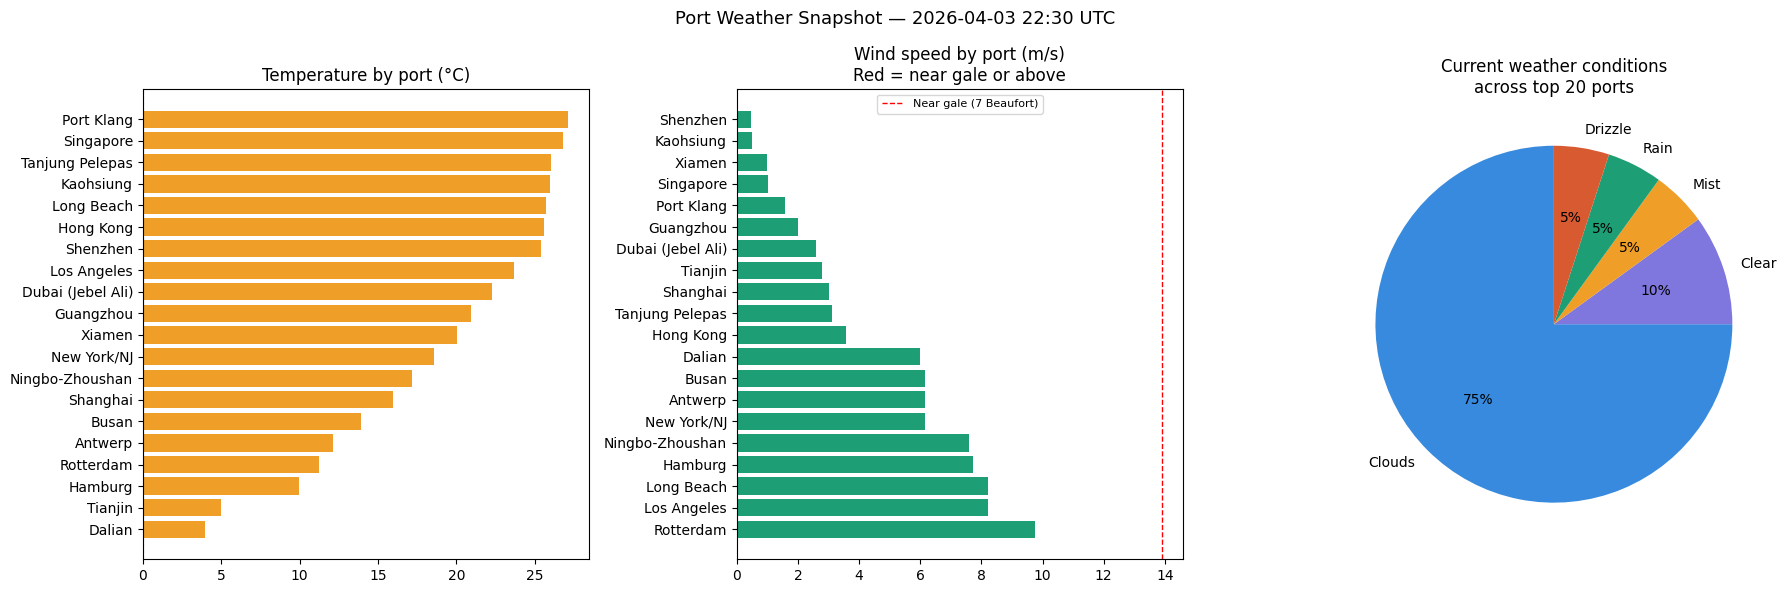

Saved → data/clean/weather_eda.png


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18,6))

# Temperature by port
df_s = df.sort_values('temp_c')
colors = ['#D85A30' if v else '#378ADD' for v in df_s['port_risk_flag']]
axes[0].barh(df_s['port_name'], df_s['temp_c'], color='#EF9F27')
axes[0].set_title('Temperature by port (°C)')
axes[0].axvline(0, color='gray', lw=0.8, ls='--')

# Wind speed by port
df_w = df.sort_values('wind_speed_ms', ascending=False)
bar_colors = ['#D85A30' if v else '#1D9E75' for v in df_w['port_risk_flag']]
axes[1].barh(df_w['port_name'], df_w['wind_speed_ms'], color=bar_colors)
axes[1].axvline(13.9, color='red', lw=1, ls='--', label='Near gale (7 Beaufort)')
axes[1].set_title('Wind speed by port (m/s)\nRed = near gale or above')
axes[1].legend(fontsize=8)

# Weather condition breakdown
weather_counts = df['weather_main'].value_counts()
axes[2].pie(weather_counts.values, labels=weather_counts.index,
            colors=['#378ADD','#7F77DD','#EF9F27','#1D9E75','#D85A30'],
            autopct='%1.0f%%', startangle=90)
axes[2].set_title('Current weather conditions\nacross top 20 ports')

plt.suptitle(f'Port Weather Snapshot — {datetime.now().strftime("%Y-%m-%d %H:%M")} UTC', fontsize=13)
plt.tight_layout()
plt.savefig(f'{CLEAN_DIR}/weather_eda.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → data/clean/weather_eda.png')

## 8. Save Clean Data

In [17]:
df.to_csv(CLEAN_PATH, index=False)
print(f'Saved → {CLEAN_PATH}')
print(f'Shape: {df.shape}')
print()
print('Summary:')
print(df[['port_name','country_iso','temp_c','wind_speed_ms','beaufort_desc','weather_main']].to_string(index=False))
print('\nDONE — run 04_combine_EDA.ipynb next')

Saved → /content/drive/MyDrive/repo/data/clean/port_weather_clean.csv
Shape: (20, 31)

Summary:
        port_name country_iso  temp_c  wind_speed_ms   beaufort_desc weather_main
         Shanghai          CN   15.95           3.00    Light breeze         Mist
        Singapore          SG   26.80           1.03       Light air       Clouds
  Ningbo-Zhoushan          CN   17.18           7.60 Moderate breeze       Clouds
         Shenzhen          CN   25.43           0.45       Light air       Clouds
        Guangzhou          CN   20.92           1.99    Light breeze       Clouds
            Busan          KR   13.91           6.17 Moderate breeze         Rain
          Tianjin          CN    5.00           2.77    Light breeze        Clear
        Hong Kong          HK   25.57           3.58   Gentle breeze       Clouds
        Rotterdam          NL   11.23           9.77    Fresh breeze       Clouds
Dubai (Jebel Ali)          AE   22.25           2.60    Light breeze       Clouds
  